In [70]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

[1.47e+08 1.40e+08]


In [71]:
P_opt = np.linspace(0,10,1) #W
w0 = 1e-6 #m
N = 3 #change me for a different number of ions

In [72]:
pot = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
w_tw_r = omega_tweezer_r(pot,w0,m) 
print("f_tw_r = ",w_tw_r/(2*pi*1e3),"kHz")

f_tw_r =  [0.] kHz


In [73]:
f_rf_r = 1e6 #Hz
w_rf_r = f_rf_r*2*pi
ueq = ion_spacing(N,f_rf_r)[0]
f_rf_r_list = np.full(N,f_rf_r)
w_rf_r_list = np.full(N,w_rf_r)


In [74]:
eta(mode_calc_r(m, w_rf_r_list, ueq, N),729.147e-9,N)[0]

[0.140241262793494, 0.14024126279349566, 0.14024126279349583]

In [75]:
def lamb_dicke(qubit_wavelength,omega_rf):
    """Inputs:
        qubit wavelength -- float of qubit wavelength, ex 729e-9 for Ca 40
        omega_rf -- secular frequency of trap in whatever direction you're considering (2*pi*Hz)

        This function assumes the incoming beam has a 100% projection on the direction you're considering. 
        If you want what the lamb dicke parameter would be for an ion in a multi-ion chain then you have to scale it by its participation
        Outputs:
        Lamb -Dicke parameter for a single ion
    """


    k = (2*pi)/qubit_wavelength
    np.sqrt((hbar*k**2) /(2*m*omega_rf) )

In [76]:

def tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    P_opt,
    w0,
    max_tweezed=2
):
    """
    Compute all tweezer combinations and corresponding radial mode frequencies,
    including power dependence and tweezed/untweezed mode separation.

    Automatically handles an arbitrary number of modes.
    """

    pi = np.pi
    rows = []

    # --- Generate all tweezer combinations up to `max_tweezed` ---
    all_combos = []
    for r in range(0, max_tweezed + 1):
        all_combos.extend(itertools.combinations(range(N), r))

    # --- Helper functions ---
    def max_with_index(arr):
        arr = np.ravel(arr)
        idx = np.argmax(arr)
        return arr[idx], idx

    def max_no_tweeze(arr, tweezed, N):
        arr = np.ravel(arr)
        ion_indices = np.arange(N)
        mask = ~np.isin(ion_indices, tweezed)
        if np.any(mask):
            arr_untweezed = arr[mask]
            ion_untweezed = ion_indices[mask]
            idx_local = np.argmax(arr_untweezed)
            return arr_untweezed[idx_local], ion_untweezed[idx_local]
        else:
            return np.nan, np.nan

    def sum_no_tweeze(arr, tweezed, N):
        arr = np.ravel(arr)
        ion_indices = np.arange(N)
        untweezed_mask = ~np.isin(ion_indices, tweezed)
        if np.any(untweezed_mask):
            return np.sqrt(np.sum(arr[untweezed_mask] ** 2))
        else:
            return np.nan

    # --- Loop over optical powers ---
    for P in P_opt:
        pot = potential(omega_tweezer, linewidths, omega_res, P, w0)
        w_tw_r = omega_tweezer_r(pot, w0, m)
        f_tw_r = w_tw_r / (2 * pi * 1e3)
        print(f"P = {P:.3f} W → f_tw_r = {f_tw_r:.3f} kHz")

        # RF trap setup
        w_rf_r = f_rf_r * 2 * pi
        ueq = ion_spacing(N, f_rf_r)[0]
        w_rf_r_list = np.full(N, w_rf_r)

        # --- Loop through all tweezer combinations ---
        for positions in all_combos:
            combo = np.array([
                np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2) if i in positions else w_rf_r_list[i]
                for i in range(N)
            ])

            # Compute radial modes
            modes = mode_calc_r(m, combo, ueq, N)
            tweezed_radial_modes = eta(modes, 729.147e-9, N)

            # --- Initialize a single row ---
            row = {
                "P_opt (W)": P,
                "Ions tweezed": positions,
                "Combined radial frequencies": combo,
                "radial_modes": tweezed_radial_modes
            }

            # --- Handle arbitrary number of modes dynamically ---
            for mode_index, mode_values in enumerate(tweezed_radial_modes):
                mode_values = np.ravel(mode_values)

                mode_sum = np.sqrt(np.sum(mode_values ** 2))
                mode_max, mode_max_index = max_with_index(mode_values)
                mode_max_no_tweeze, mode_max_no_tweeze_index = max_no_tweeze(mode_values, positions, N)
                mode_sum_no_tweeze = sum_no_tweeze(mode_values, positions, N)

                # Store dynamically
                row[f"Mode{mode_index}"] = mode_values
                row[f"Mode{mode_index}_sum"] = mode_sum
                row[f"Mode{mode_index}_sum_no_tweeze"] = mode_sum_no_tweeze
                row[f"Mode{mode_index}_max"] = mode_max
                row[f"Mode{mode_index}_max_index"] = mode_max_index
                row[f"Mode{mode_index}_max_no_tweeze"] = mode_max_no_tweeze
                row[f"Mode{mode_index}_max_no_tweeze_index"] = mode_max_no_tweeze_index

            # --- Store the completed row ---
            rows.append(row)

    return pd.DataFrame(rows)


In [77]:
N = 3
P_opt = np.linspace(0,1,20) #W
#print(P_opt)
w0 = 1e-6
f_rf_r = 1e6
data = tweezer_combos_full_radial(omega_tweezer, linewidths, omega_res, m, mode_calc_r, N, f_rf_r, P_opt, w0)


P = 0.000 W → f_tw_r = 0.000 kHz
P = 0.053 W → f_tw_r = 231.680 kHz
P = 0.105 W → f_tw_r = 327.645 kHz
P = 0.158 W → f_tw_r = 401.282 kHz
P = 0.211 W → f_tw_r = 463.360 kHz
P = 0.263 W → f_tw_r = 518.053 kHz
P = 0.316 W → f_tw_r = 567.498 kHz
P = 0.368 W → f_tw_r = 612.968 kHz
P = 0.421 W → f_tw_r = 655.290 kHz
P = 0.474 W → f_tw_r = 695.040 kHz
P = 0.526 W → f_tw_r = 732.637 kHz
P = 0.579 W → f_tw_r = 768.396 kHz
P = 0.632 W → f_tw_r = 802.564 kHz
P = 0.684 W → f_tw_r = 835.335 kHz
P = 0.737 W → f_tw_r = 866.868 kHz
P = 0.789 W → f_tw_r = 897.293 kHz
P = 0.842 W → f_tw_r = 926.721 kHz
P = 0.895 W → f_tw_r = 955.242 kHz
P = 0.947 W → f_tw_r = 982.936 kHz
P = 1.000 W → f_tw_r = 1009.870 kHz


In [78]:
Untweezed = data[data['Ions tweezed']==()]
Tweeze0 = data[data['Ions tweezed']==(0,)]
Tweeze1 = data[data['Ions tweezed']==(1,)]
Tweeze2 = data[data['Ions tweezed']==(2,)]
Tweeze01 = data[data['Ions tweezed']==(0,1)]
Tweeze02 = data[data['Ions tweezed']==(0,2)]
Tweeze12 = data[data['Ions tweezed']==(1,2)]

In [79]:
Untweezed


,P_opt (W),Ions tweezed,Combined radial frequencies,radial_modes,Mode0,Mode0_sum,Mode0_sum_no_tweeze,Mode0_max,Mode0_max_index,Mode0_max_no_tweeze,...,Mode1_max_index,Mode1_max_no_tweeze,Mode1_max_no_tweeze_index,Mode2,Mode2_sum,Mode2_sum_no_tweeze,Mode2_max,Mode2_max_index,Mode2_max_no_tweeze,Mode2_max_no_tweeze_index
0,0.000000,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
7,0.052632,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
14,0.105263,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
21,0.157895,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
28,0.210526,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
35,0.263158,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
42,0.315789,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
49,0.368421,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
56,0.421053,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1
63,0.473684,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.140241262793494, 0.14024126279349566, 0.14...","[0.140241262793494, 0.14024126279349566, 0.140...",0.242905,0.242905,0.140241,2,0.140241,...,0,0.172865,0,"[-0.10073269475570484, 0.20146538951143378, -0...",0.246744,0.246744,0.201465,1,0.201465,1


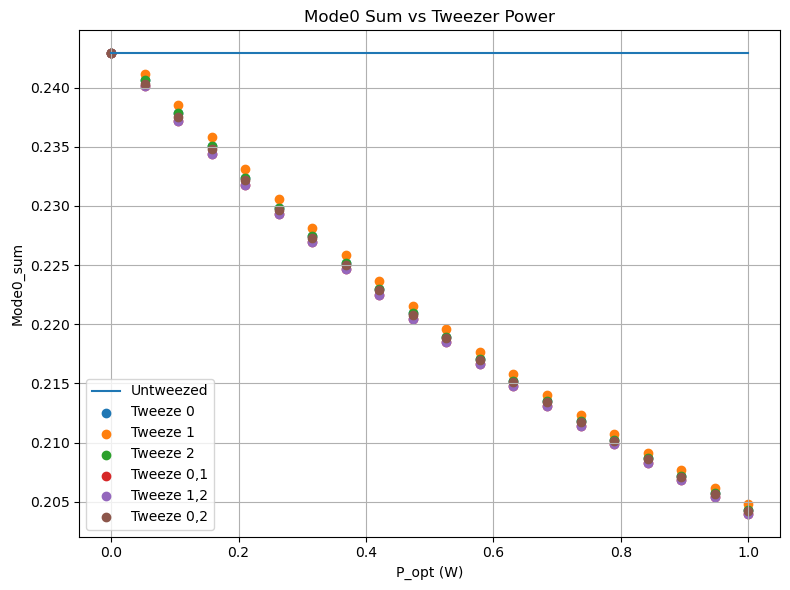

In [80]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_sum'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_sum'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_sum'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_sum'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_sum'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_sum'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_sum'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0_sum")
plt.title("Mode0 Sum vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

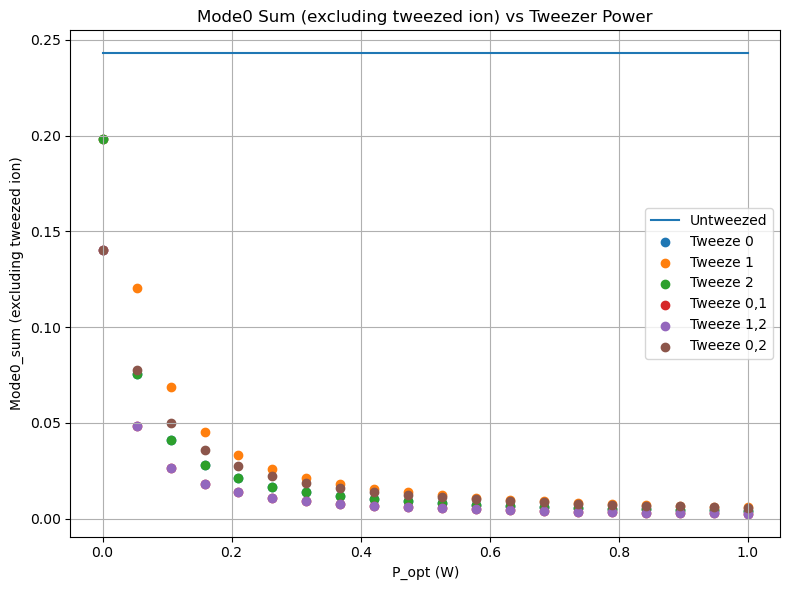

In [81]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_sum_no_tweeze'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_sum_no_tweeze'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_sum_no_tweeze'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_sum_no_tweeze'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_sum_no_tweeze'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_sum_no_tweeze'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_sum_no_tweeze'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0_sum (excluding tweezed ion)")
plt.title("Mode0 Sum (excluding tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

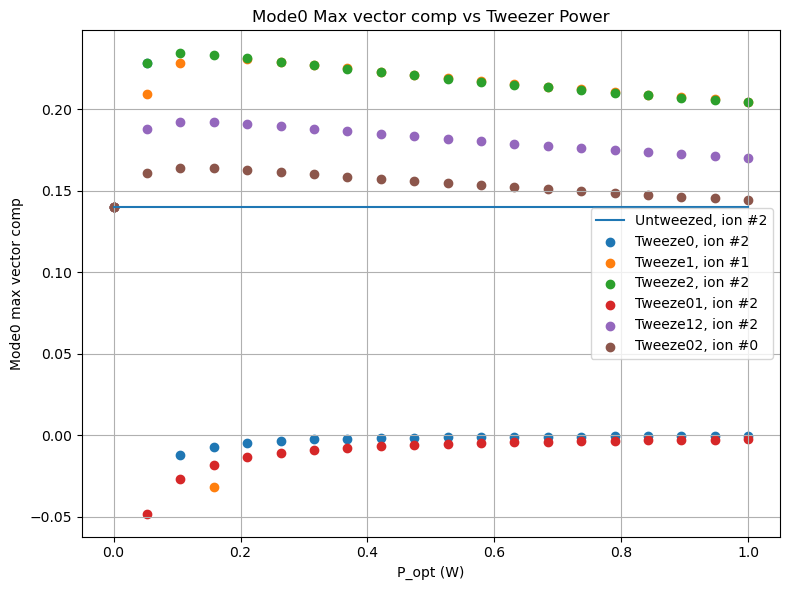

In [82]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_max'], label=f"Untweezed, ion #{Untweezed['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_max'],label = f"Tweeze0, ion #{Tweeze0['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_max'], label = f"Tweeze1, ion #{Tweeze1['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_max'], label = f"Tweeze2, ion #{Tweeze2['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_max'], label = f"Tweeze01, ion #{Tweeze01['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_max'], label = f"Tweeze12, ion #{Tweeze12['Mode0_max_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_max'], label = f"Tweeze02, ion #{Tweeze02['Mode0_max_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0 max vector comp")
plt.title("Mode0 Max vector comp vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

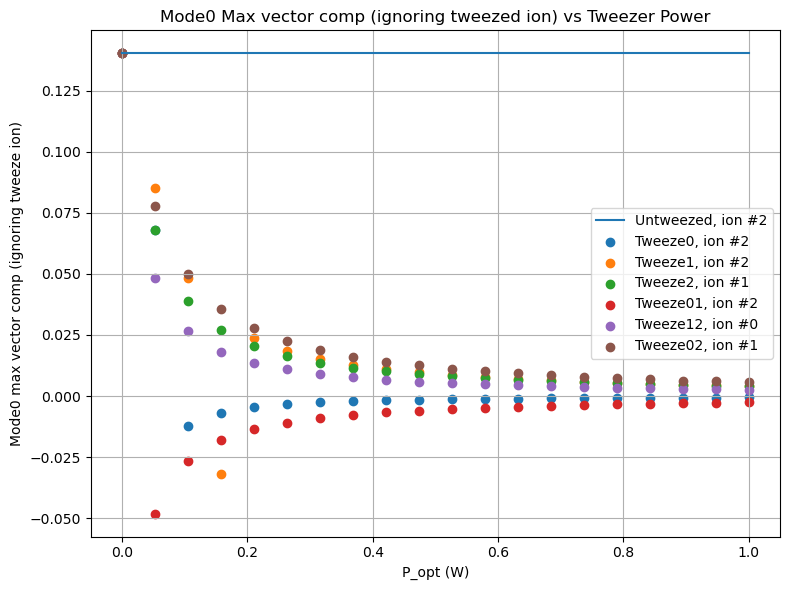

In [83]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode0_max_no_tweeze'], label=f"Untweezed, ion #{Untweezed['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode0_max_no_tweeze'],label = f"Tweeze0, ion #{Tweeze0['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode0_max_no_tweeze'], label = f"Tweeze1, ion #{Tweeze1['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode0_max_no_tweeze'], label = f"Tweeze2, ion #{Tweeze2['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode0_max_no_tweeze'], label = f"Tweeze01, ion #{Tweeze01['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode0_max_no_tweeze'], label = f"Tweeze12, ion #{Tweeze12['Mode0_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode0_max_no_tweeze'], label = f"Tweeze02, ion #{Tweeze02['Mode0_max_no_tweeze_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0 max vector comp (ignoring tweeze ion)")
plt.title("Mode0 Max vector comp (ignoring tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

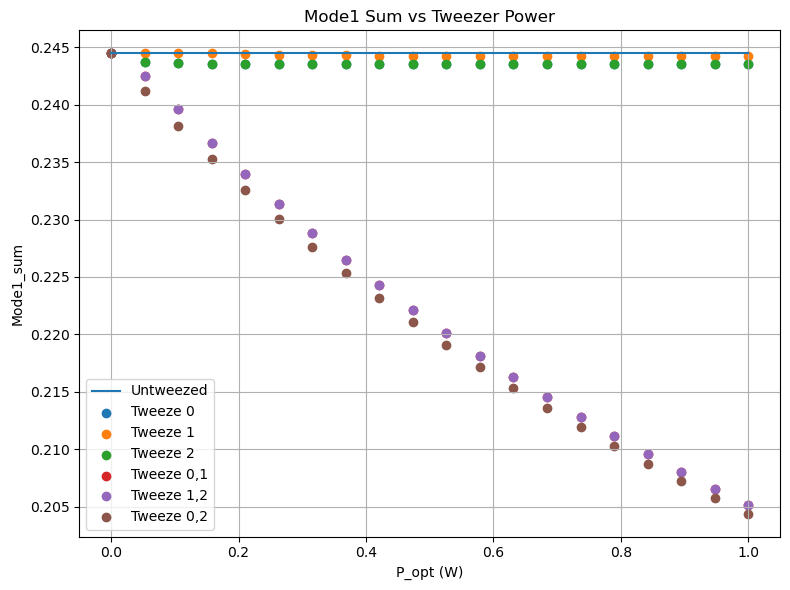

In [84]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_sum'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_sum'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_sum'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_sum'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_sum'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_sum'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_sum'], label="Tweeze 0,2")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode1_sum")
plt.title("Mode1 Sum vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

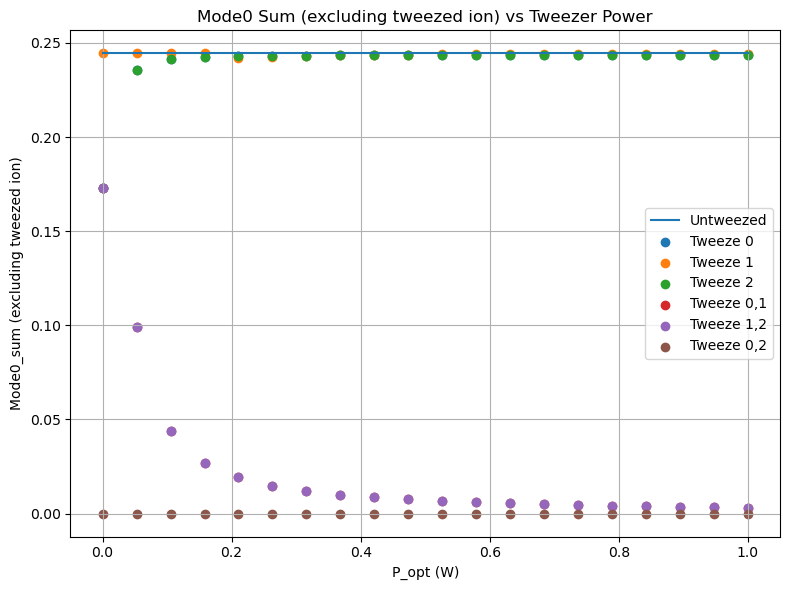

In [85]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_sum_no_tweeze'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_sum_no_tweeze'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_sum_no_tweeze'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_sum_no_tweeze'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_sum_no_tweeze'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_sum_no_tweeze'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_sum_no_tweeze'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode0_sum (excluding tweezed ion)")
plt.title("Mode0 Sum (excluding tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

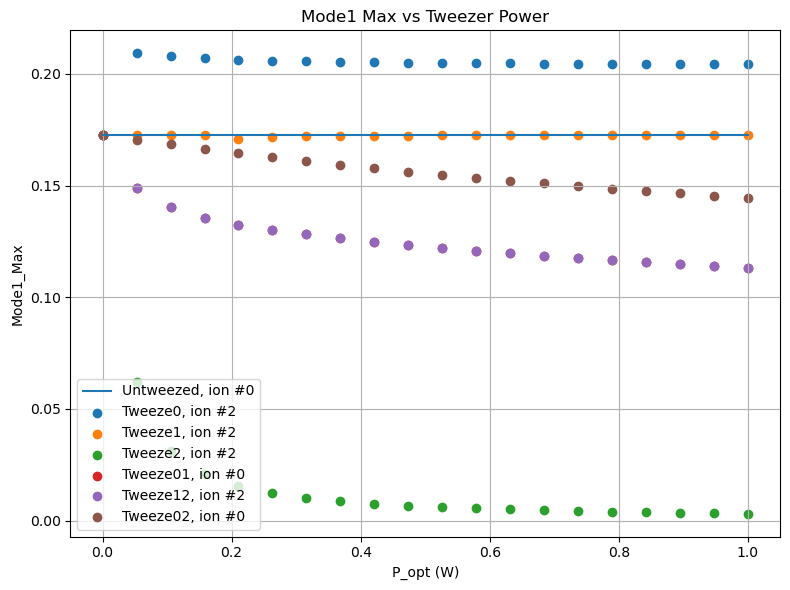

In [86]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_max'], label = f"Untweezed, ion #{Untweezed['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_max'],  label = f"Tweeze0, ion #{Tweeze0['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_max'],  label = f"Tweeze1, ion #{Tweeze1['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_max'],  label = f"Tweeze2, ion #{Tweeze1['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_max'],  label = f"Tweeze01, ion #{Tweeze01['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_max'],  label = f"Tweeze12, ion #{Tweeze12['Mode1_max_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_max'],  label = f"Tweeze02, ion #{Tweeze02['Mode1_max_index'].iloc[2]}")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode1_Max")
plt.title("Mode1 Max vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

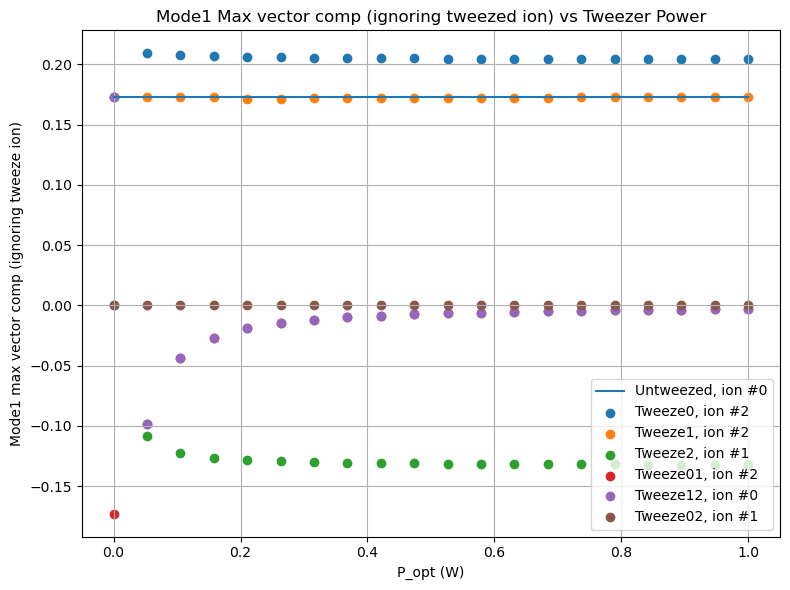

In [87]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode1_max_no_tweeze'], label=f"Untweezed, ion #{Untweezed['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode1_max_no_tweeze'],label = f"Tweeze0, ion #{Tweeze0['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode1_max_no_tweeze'], label = f"Tweeze1, ion #{Tweeze1['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode1_max_no_tweeze'], label = f"Tweeze2, ion #{Tweeze2['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode1_max_no_tweeze'], label = f"Tweeze01, ion #{Tweeze01['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode1_max_no_tweeze'], label = f"Tweeze12, ion #{Tweeze12['Mode1_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode1_max_no_tweeze'], label = f"Tweeze02, ion #{Tweeze02['Mode1_max_no_tweeze_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode1 max vector comp (ignoring tweeze ion)")
plt.title("Mode1 Max vector comp (ignoring tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

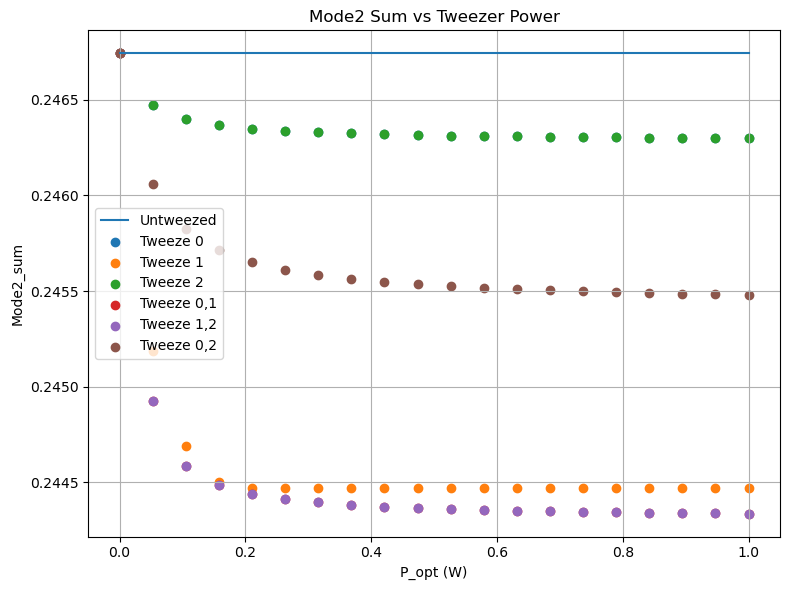

In [88]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_sum'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_sum'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_sum'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_sum'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_sum'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_sum'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_sum'], label="Tweeze 0,2")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode2_sum")
plt.title("Mode2 Sum vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

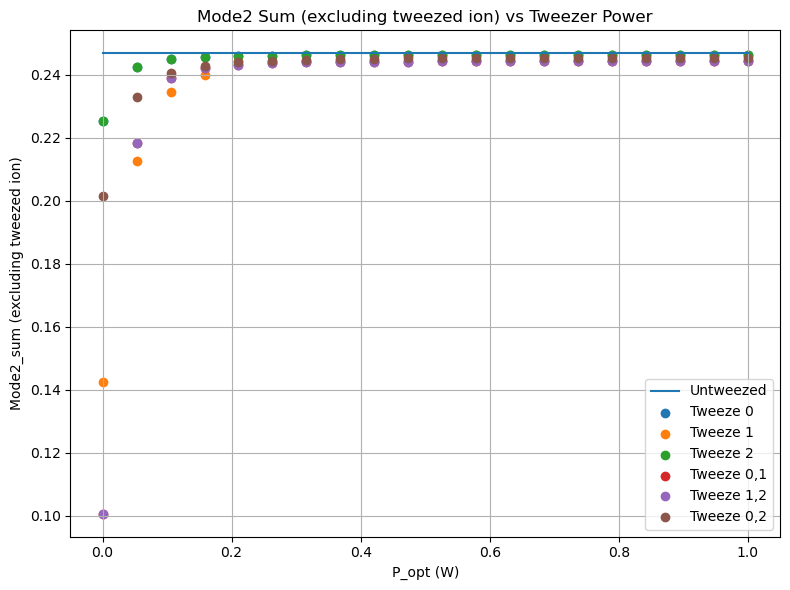

In [89]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_sum_no_tweeze'], label="Untweezed")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_sum_no_tweeze'], label="Tweeze 0")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_sum_no_tweeze'], label="Tweeze 1")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_sum_no_tweeze'], label="Tweeze 2")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_sum_no_tweeze'], label="Tweeze 0,1")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_sum_no_tweeze'], label="Tweeze 1,2")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_sum_no_tweeze'], label="Tweeze 0,2")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode2_sum (excluding tweezed ion)")
plt.title("Mode2 Sum (excluding tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

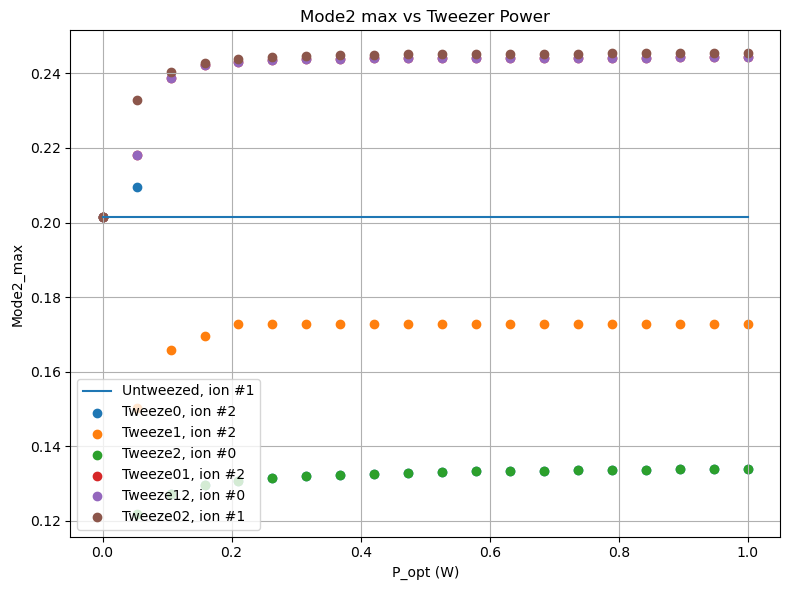

In [90]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_max'], label = f"Untweezed, ion #{Untweezed['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_max'], label = f"Tweeze0, ion #{Tweeze0['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_max'],label = f"Tweeze1, ion #{Tweeze1['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_max'], label = f"Tweeze2, ion #{Tweeze2['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_max'], label = f"Tweeze01, ion #{Tweeze01['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_max'], label = f"Tweeze12, ion #{Tweeze12['Mode2_max_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_max'], label = f"Tweeze02, ion #{Tweeze02['Mode2_max_index'].iloc[2]}")

plt.xlabel("P_opt (W)")
plt.ylabel("Mode2_max")
plt.title("Mode2 max vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

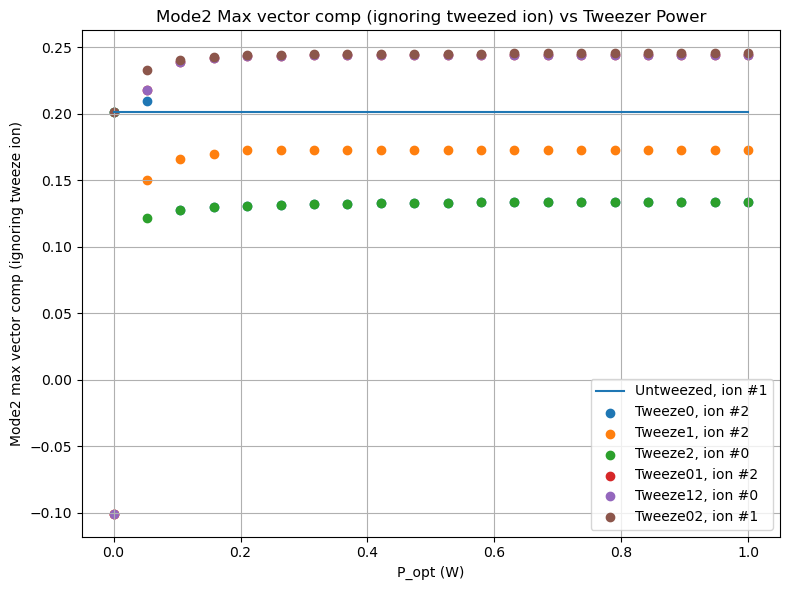

In [91]:
plt.figure(figsize=(8,6))

plt.plot(Untweezed['P_opt (W)'], Untweezed['Mode2_max_no_tweeze'], label=f"Untweezed, ion #{Untweezed['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze0['P_opt (W)'], Tweeze0['Mode2_max_no_tweeze'],label = f"Tweeze0, ion #{Tweeze0['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze1['P_opt (W)'], Tweeze1['Mode2_max_no_tweeze'], label = f"Tweeze1, ion #{Tweeze1['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze2['P_opt (W)'], Tweeze2['Mode2_max_no_tweeze'], label = f"Tweeze2, ion #{Tweeze2['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze01['P_opt (W)'], Tweeze01['Mode2_max_no_tweeze'], label = f"Tweeze01, ion #{Tweeze01['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze12['P_opt (W)'], Tweeze12['Mode2_max_no_tweeze'], label = f"Tweeze12, ion #{Tweeze12['Mode2_max_no_tweeze_index'].iloc[2]}")
plt.scatter(Tweeze02['P_opt (W)'], Tweeze02['Mode2_max_no_tweeze'], label = f"Tweeze02, ion #{Tweeze02['Mode2_max_no_tweeze_index'].iloc[2]}")


plt.xlabel("P_opt (W)")
plt.ylabel("Mode2 max vector comp (ignoring tweeze ion)")
plt.title("Mode2 Max vector comp (ignoring tweezed ion) vs Tweezer Power")
plt.legend(loc = "best")
plt.grid(True)
plt.tight_layout()
plt.show()

In [98]:
N = 10
P_opt = np.linspace(0.1,0.5,2) #W
#print(P_opt)
w0 = 1e-6
f_rf_r = 1e6
dataN10 = tweezer_combos_full_radial(omega_tweezer, linewidths, omega_res, m, mode_calc_r, N, f_rf_r, P_opt, w0,max_tweezed=4)

P = 0.100 W → f_tw_r = 319.349 kHz
P = 0.500 W → f_tw_r = 714.086 kHz


In [99]:
dataN10

,P_opt (W),Ions tweezed,Combined radial frequencies,radial_modes,Mode0,Mode0_sum,Mode0_sum_no_tweeze,Mode0_max,Mode0_max_index,Mode0_max_no_tweeze,...,Mode8_max_index,Mode8_max_no_tweeze,Mode8_max_no_tweeze_index,Mode9,Mode9_sum,Mode9_sum_no_tweeze,Mode9_max,Mode9_max_index,Mode9_max_no_tweeze,Mode9_max_no_tweeze_index
0,0.1,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.07681330312500673, 0.07681330312500703, 0....","[0.07681330312500673, 0.07681330312500703, 0.0...",0.242905,0.242905,0.076813,9,0.076813,...,7,0.095181,7,"[-0.0005278911677161393, 0.007530448510466062,...",0.294150,0.294150,0.173455,5,0.173455,5
1,0.1,"(0,)","[6595799.989691874, 6283185.307179586, 6283185...","[[0.22029894688780144, 0.07487780270622596, 0....","[0.22029894688780144, 0.07487780270622596, 0.0...",0.239821,0.094775,0.220299,0,0.074878,...,6,0.152622,6,"[0.00043137898369331436, -0.007515318244057293...",0.294150,0.294150,0.173455,4,0.173455,4
2,0.1,"(1,)","[6283185.307179586, 6595799.989691874, 6283185...","[[-0.1054048830311946, -0.16545442014074882, -...","[-0.1054048830311946, -0.16545442014074882, -0...",0.241283,0.175620,-0.018422,9,-0.018422,...,7,0.096316,7,"[-0.00032627696909782116, 0.005746461530439452...",0.294142,0.294086,0.173625,5,0.173625,5
3,0.1,"(2,)","[6283185.307179586, 6283185.307179586, 6595799...","[[0.07915355282153039, 0.09914524221057625, 0....","[0.07915355282153039, 0.09914524221057625, 0.1...",0.241702,0.199100,0.137038,2,0.099145,...,6,0.159910,6,"[0.00037711725387065643, -0.004539619002257521...",0.293953,0.292726,0.173626,4,0.173626,4
4,0.1,"(3,)","[6283185.307179586, 6283185.307179586, 6283185...","[[-0.0655717109042676, -0.07791799809481653, -...","[-0.0655717109042676, -0.07791799809481653, -0...",0.241862,0.207739,-0.040321,9,-0.040321,...,6,0.154942,6,"[0.00029396841188891656, -0.004855172425186208...",0.292789,0.284930,0.164564,4,0.164564,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,0.5,"(5, 6, 7, 8)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.0006028424569283174, 0.0012856158602689628...","[0.0006028424569283174, 0.0012856158602689628,...",0.220892,0.024614,0.128974,7,0.017740,...,2,0.188844,2,"[-0.0018218557396627822, 0.02220092152678562, ...",0.286318,0.284071,0.191883,3,0.191883,3
768,0.5,"(5, 6, 7, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.0004068803944214888, 0.0008451082031151976...","[0.0004068803944214888, 0.0008451082031151976,...",0.221274,0.031436,0.192550,9,0.029062,...,2,0.188844,2,"[0.0018218718161234113, -0.02220088027531072, ...",0.286318,0.284071,0.186114,4,0.186114,4
769,0.5,"(5, 6, 8, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[-0.00023861052003428798, -0.0004588059669395...","[-0.00023861052003428798, -0.00045880596693958...",0.220608,0.021186,-0.000239,0,-0.000239,...,4,0.147781,4,"[-0.0018220325286291256, 0.02219627169453846, ...",0.286319,0.284067,0.191864,3,0.191864,3
770,0.5,"(5, 7, 8, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.00024027589189422563, 0.000448175986009449...","[0.00024027589189422563, 0.0004481759860094492...",0.220231,0.016396,0.173744,9,0.015709,...,2,0.084775,2,"[-0.0017975741384942156, 0.02203816812960755, ...",0.286369,0.283800,0.191154,3,0.191154,3


In [103]:
def split_by_tweeze(data):
    """
    Split a DataFrame into sub-DataFrames by unique 'Ions tweezed' combinations.
    
    Parameters
    ----------
    data : pandas.DataFrame
        The DataFrame with a column 'Ions tweezed' containing tuples.
    
    Returns
    -------
    dict
        Dictionary mapping a readable label (e.g. 'Tweeze01') to sub-DataFrame.
    """
    split_data = {}
    for combo in data['Ions tweezed'].unique():
        if combo == ():
            name = "Untweezed"
        else:
            name = "Tweeze" + "".join(map(str, combo))
        split_data[name] = data[data['Ions tweezed'] == combo]
    return split_data

def split_by_mode(data, N):
    """
    Split a DataFrame into N sub-DataFrames, each including all rows and all
    shared (non-mode) columns, but only the mode-specific columns for that mode.
    """
    split_modes = {}

    # Identify shared columns (not specific to any mode)
    shared_cols = [c for c in data.columns if not c.startswith("Mode")]

    for i in range(N):
        mode = f"Mode{i}"
        mode_cols = [c for c in data.columns if c.startswith(mode)]
        cols = shared_cols + mode_cols
        split_modes[mode] = data[cols].copy()

    return split_modes


In [104]:
split_by_tweezers_N10 = split_by_tweeze(dataN10)
split_by_modes_N10 = split_by_mode(dataN10,N)


In [ ]:
split_by_modes_N10["Mode0"]

,P_opt (W),Ions tweezed,Combined radial frequencies,radial_modes,Mode0,Mode0_sum,Mode0_sum_no_tweeze,Mode0_max,Mode0_max_index,Mode0_max_no_tweeze,Mode0_max_no_tweeze_index
0,0.1,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.07681330312500673, 0.07681330312500703, 0....","[0.07681330312500673, 0.07681330312500703, 0.0...",0.242905,0.242905,0.076813,9,0.076813,9
1,0.1,"(0,)","[6595799.989691874, 6283185.307179586, 6283185...","[[0.22029894688780144, 0.07487780270622596, 0....","[0.22029894688780144, 0.07487780270622596, 0.0...",0.239821,0.094775,0.220299,0,0.074878,1
2,0.1,"(1,)","[6283185.307179586, 6595799.989691874, 6283185...","[[-0.1054048830311946, -0.16545442014074882, -...","[-0.1054048830311946, -0.16545442014074882, -0...",0.241283,0.175620,-0.018422,9,-0.018422,9
3,0.1,"(2,)","[6283185.307179586, 6283185.307179586, 6595799...","[[0.07915355282153039, 0.09914524221057625, 0....","[0.07915355282153039, 0.09914524221057625, 0.1...",0.241702,0.199100,0.137038,2,0.099145,1
4,0.1,"(3,)","[6283185.307179586, 6283185.307179586, 6283185...","[[-0.0655717109042676, -0.07791799809481653, -...","[-0.0655717109042676, -0.07791799809481653, -0...",0.241862,0.207739,-0.040321,9,-0.040321,9
...,...,...,...,...,...,...,...,...,...,...,...
767,0.5,"(5, 6, 7, 8)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.0006028424569283174, 0.0012856158602689628...","[0.0006028424569283174, 0.0012856158602689628,...",0.220892,0.024614,0.128974,7,0.017740,4
768,0.5,"(5, 6, 7, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.0004068803944214888, 0.0008451082031151976...","[0.0004068803944214888, 0.0008451082031151976,...",0.221274,0.031436,0.192550,9,0.029062,8
769,0.5,"(5, 6, 8, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[-0.00023861052003428798, -0.0004588059669395...","[-0.00023861052003428798, -0.00045880596693958...",0.220608,0.021186,-0.000239,0,-0.000239,0
770,0.5,"(5, 7, 8, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.00024027589189422563, 0.000448175986009449...","[0.00024027589189422563, 0.0004481759860094492...",0.220231,0.016396,0.173744,9,0.015709,6


In [106]:
split_by_modes_N10["Mode9"]

,P_opt (W),Ions tweezed,Combined radial frequencies,radial_modes,Mode9,Mode9_sum,Mode9_sum_no_tweeze,Mode9_max,Mode9_max_index,Mode9_max_no_tweeze,Mode9_max_no_tweeze_index
0,0.1,(),"[6283185.307179586, 6283185.307179586, 6283185...","[[0.07681330312500673, 0.07681330312500703, 0....","[-0.0005278911677161393, 0.007530448510466062,...",0.294150,0.294150,0.173455,5,0.173455,5
1,0.1,"(0,)","[6595799.989691874, 6283185.307179586, 6283185...","[[0.22029894688780144, 0.07487780270622596, 0....","[0.00043137898369331436, -0.007515318244057293...",0.294150,0.294150,0.173455,4,0.173455,4
2,0.1,"(1,)","[6283185.307179586, 6595799.989691874, 6283185...","[[-0.1054048830311946, -0.16545442014074882, -...","[-0.00032627696909782116, 0.005746461530439452...",0.294142,0.294086,0.173625,5,0.173625,5
3,0.1,"(2,)","[6283185.307179586, 6283185.307179586, 6595799...","[[0.07915355282153039, 0.09914524221057625, 0....","[0.00037711725387065643, -0.004539619002257521...",0.293953,0.292726,0.173626,4,0.173626,4
4,0.1,"(3,)","[6283185.307179586, 6283185.307179586, 6283185...","[[-0.0655717109042676, -0.07791799809481653, -...","[0.00029396841188891656, -0.004855172425186208...",0.292789,0.284930,0.164564,4,0.164564,4
...,...,...,...,...,...,...,...,...,...,...,...
767,0.5,"(5, 6, 7, 8)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.0006028424569283174, 0.0012856158602689628...","[-0.0018218557396627822, 0.02220092152678562, ...",0.286318,0.284071,0.191883,3,0.191883,3
768,0.5,"(5, 6, 7, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.0004068803944214888, 0.0008451082031151976...","[0.0018218718161234113, -0.02220088027531072, ...",0.286318,0.284071,0.186114,4,0.186114,4
769,0.5,"(5, 6, 8, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[-0.00023861052003428798, -0.0004588059669395...","[-0.0018220325286291256, 0.02219627169453846, ...",0.286319,0.284067,0.191864,3,0.191864,3
770,0.5,"(5, 7, 8, 9)","[6283185.307179586, 6283185.307179586, 6283185...","[[0.00024027589189422563, 0.000448175986009449...","[-0.0017975741384942156, 0.02203816812960755, ...",0.286369,0.283800,0.191154,3,0.191154,3
